In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [27]:
df = pd.read_csv('train (1).csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [28]:
df.drop(['PassengerId','Pclass','Name','Sex','Ticket','Cabin','Embarked'],axis = 1,inplace = True)

In [29]:
df

,Survived,Age,SibSp,Parch,Fare
0,0,22.0,1,0,7.2500
1,1,38.0,1,0,71.2833
2,1,26.0,0,0,7.9250
3,1,35.0,1,0,53.1000
4,0,35.0,0,0,8.0500
...,...,...,...,...,...
886,0,27.0,0,0,13.0000
887,1,19.0,0,0,30.0000
888,0,NaN,1,2,23.4500
889,1,26.0,0,0,30.0000


In [31]:
df['Family'] = df['SibSp'] + df['Parch']

In [32]:
df

,Survived,Age,SibSp,Parch,Fare,Family
0,0,22.0,1,0,7.2500,1
1,1,38.0,1,0,71.2833,1
2,1,26.0,0,0,7.9250,0
3,1,35.0,1,0,53.1000,1
4,0,35.0,0,0,8.0500,0
...,...,...,...,...,...,...
886,0,27.0,0,0,13.0000,0
887,1,19.0,0,0,30.0000,0
888,0,NaN,1,2,23.4500,3
889,1,26.0,0,0,30.0000,0


In [34]:
df.drop(columns = ['SibSp','Parch'],axis = 1,inplace = True)

In [35]:
df


,Survived,Age,Fare,Family
0,0,22.0,7.2500,1
1,1,38.0,71.2833,1
2,1,26.0,7.9250,0
3,1,35.0,53.1000,1
4,0,35.0,8.0500,0
...,...,...,...,...
886,0,27.0,13.0000,0
887,1,19.0,30.0000,0
888,0,NaN,23.4500,3
889,1,26.0,30.0000,0


In [66]:
df.to_csv("titanic_toy.csv",index=False)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   Fare      891 non-null    float64
 3   Family    891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [37]:
df.isnull().mean()

Survived    0.000000
Age         0.198653
Fare        0.000000
Family      0.000000
dtype: float64

In [38]:
idx = df.sample(frac=0.05,random_state=42).index

df.loc[idx,'Fare'] = np.nan

In [39]:
df.isnull().mean()

Survived    0.000000
Age         0.198653
Fare        0.050505
Family      0.000000
dtype: float64

In [40]:
X = df.drop(columns = 'Survived')
y = df['Survived']

In [42]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [43]:
X_train.shape, X_test.shape

((712, 3), (179, 3))

In [44]:
X_train.isnull().mean()

Age       0.207865
Fare      0.050562
Family    0.000000
dtype: float64

In [46]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()

In [47]:
X_train['Age_median'] = X_train['Age'].fillna(median_age)
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)

X_train['Fare_median'] = X_train['Fare'].fillna(median_age)
X_train['Fare_mean'] = X_train['Fare'].fillna(mean_age)

In [49]:
X_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
437,24.0,18.7500,5,24.00,24.000000,18.7500,18.7500
457,NaN,51.8625,1,28.75,29.785904,51.8625,51.8625
347,NaN,16.1000,1,28.75,29.785904,16.1000,16.1000
655,24.0,73.5000,2,24.00,24.000000,73.5000,73.5000
658,23.0,13.0000,0,23.00,23.000000,13.0000,13.0000


In [50]:
print('Original Age variable variance :',X_train['Age'].var())
print('Age Variance after median imputation:',X_train['Age_median'].var())
print('Age Variance after mean imputation:',X_train['Age_mean'].var())

print('Original Fare variable variance :',X_train['Fare'].var())
print('Fare Variance after median imputation:',X_train['Fare_median'].var())
print('Fare Variance after mean imputation:',X_train['Fare_mean'].var())


Original Age variable variance : 204.34951339046142
Age Variance after median imputation: 161.98956633460548
Age Variance after mean imputation: 161.81262452718676
Original Fare variable variance : 2470.643159145907
Fare Variance after median imputation: 2346.35550646571
Fare Variance after mean imputation: 2345.9987177081393


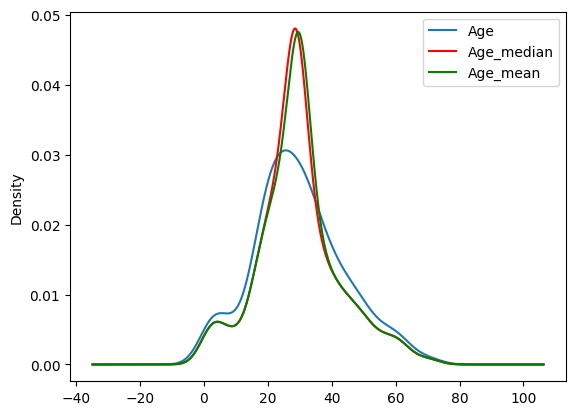

In [52]:
fig = plt.figure()

ax = fig.add_subplot(111)

# original variable distribution
X_train['Age'].plot(kind = 'kde',ax=ax)

# variable imputed with the mean
X_train['Age_median'].plot(kind='kde',ax=ax,color='red')

# variable imputed with the mean
X_train['Age_mean'].plot(kind='kde',ax=ax,color='green')


lines,labels = ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

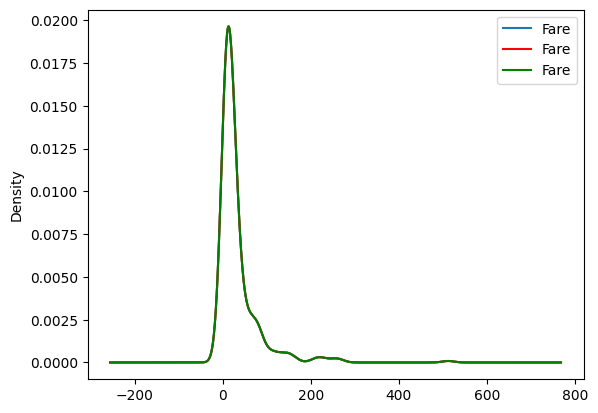

In [53]:
fig = plt.figure()

ax = fig.add_subplot(111)

# original variable distribution
X_train['Fare'].plot(kind = 'kde',ax=ax)

# variable imputed with the mean
X_train['Fare'].plot(kind='kde',ax=ax,color='red')

# variable imputed with the mean
X_train['Fare'].plot(kind='kde',ax=ax,color='green')


lines,labels = ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

In [54]:
X_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,204.349513,73.136773,-6.498901,204.349513,204.349513,70.755902,70.588060
Fare,73.136773,2470.643159,17.347633,60.812684,58.461555,2470.643159,2470.643159
Family,-6.498901,17.347633,2.735252,-5.112563,-5.146106,16.507178,16.497601
Age_median,204.349513,60.812684,-5.112563,161.989566,161.812625,58.268673,58.133480
Age_mean,204.349513,58.461555,-5.146106,161.812625,161.812625,56.027528,55.894624
Fare_median,70.755902,2470.643159,16.507178,58.268673,56.027528,2346.355506,2346.151319
Fare_mean,70.588060,2470.643159,16.497601,58.133480,55.894624,2346.151319,2345.998718


In [55]:
X_train.corr()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,0.095289,-0.299113,1.000000,1.000000,0.095193,0.094978
Fare,0.095289,1.000000,0.209196,0.095217,0.091600,1.000000,1.000000
Family,-0.299113,0.209196,1.000000,-0.242883,-0.244610,0.206052,0.205948
Age_median,1.000000,0.095217,-0.242883,1.000000,0.999454,0.094514,0.094302
Age_mean,1.000000,0.091600,-0.244610,0.999454,1.000000,0.090928,0.090719
Fare_median,0.095193,1.000000,0.206052,0.094514,0.090928,1.000000,0.999989
Fare_mean,0.094978,1.000000,0.205948,0.094302,0.090719,0.999989,1.000000


<Axes: >

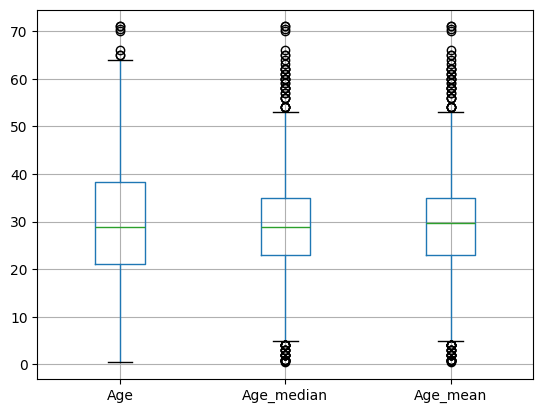

In [56]:
X_train[['Age','Age_median','Age_mean']].boxplot()

<Axes: >

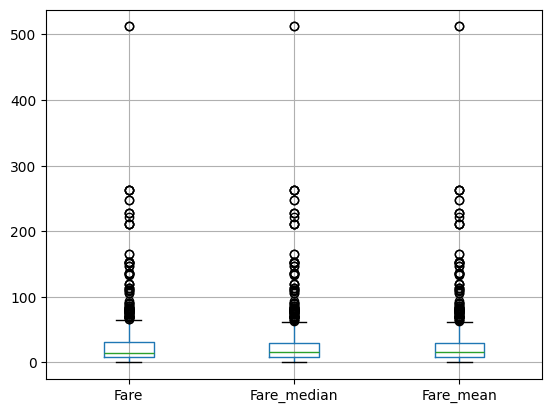

In [57]:
X_train[['Fare','Fare_median','Fare_mean']].boxplot()

Using ScikitLearn

In [58]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [59]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')


In [60]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder = 'passthrough')

In [61]:
trf.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer1', ...), ('imputer2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featu

In [62]:
trf.named_transformers_['imputer1'].statistics_

array([28.75])

In [63]:
trf.named_transformers_['imputer2'].statistics_

array([32.85025207])

In [64]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [65]:
X_train

array([[ 40.        ,  32.85025207,   0.        ],
       [  4.        ,  16.7       ,   2.        ],
       [ 47.        ,   9.        ,   0.        ],
       ...,
       [ 71.        ,  49.5042    ,   0.        ],
       [ 28.75      , 221.7792    ,   0.        ],
       [ 28.75      ,  25.925     ,   0.        ]], shape=(712, 3))